# CTE analysis 
In this notebook we showcase a workflow to determine the Coefficient of Thermal Expansion (CTE) for a small toy system, a SiO2 glass. Furthermore, we show the output of a proper that uses more reliable settings.


# CTE workflow in a nutshell
The `cte_simulation` workflow is used to compute CTE values for the defined structure. In essence, the workflow is designed as follows:
1. Short NVT run to equilibrate temperature (hard-coded)
2. NPT run to equilibrate pressure
3. NPT production phase, split over individual "runs".
4. Computing CTE after every "run" and compare to previous value:
    - If CTE is converged, continue with the next temperature 
    - If maximum number of specified runs is reached, continue with the next temperature
    - Else, continue with another "run"

A typical call of the cte workflow looks as follows:
```python
########################################################################################
cte_delayed = cte_simulation(
    structure=structure_glass,         # Initial structure (ase.Atoms)
    potential=generated_potential,     # Use the specified potential
    temperature=[300, 400, 500],       # Loop over these temperatures in the given order
    pressure=1e-4,                     # Target pressure in pyiron units (GPa). 1e-4 GPa = 1 bar
    aniso=True,                        # Whether to run in lammps aniso mode. If False use iso settings
    timestep=1.0,                      # Timestep in fs
    equilibration_steps=50_000,        # Number of steps for NPT equilibration
    production_steps=200_000,          # Number of steps for each NPT production run
    max_production_runs=25,            # Maximum number of production runs
    CTE_convergence_criterion=5e-7,    # Convergence criterion for CTE
    n_dump=100_000,                    # How often structure are dumped during production runs
    n_log=5,                           # How often thermodynamic output is written to log
    server_kwargs=server_kwargs,       # Specify details on computational resources
    seed=12345,                        # Seed to initialize velocities for first NVT equilibration
    pyiron_project=pr,                 # Pyiron project
)

cte_results = cte_delayed.pull()
########################################################################################
```

The output of the workflow is a nested dictionary with the main keys relating to the temperature of the form "01_300K", "02_400K", etc. The initial number indicates the order of the temperature sequence and allows calculating the same temperature multiple times in the sequence. Under every temperature key, a key relating to the production run in the form of "run01", "run02", etc. is present. Each production run key contains the computed CTE value and other thermodynamic and structural properties calculated with all data up to this run. Finally, additional keys are present that indicate whether the CTE has converged, the convergence criterion and the final structure at the end of the last production run.: 

```python
{
  "01_300K": {
    'run01': {
      'CTE_V': ...,
      'CTE_x': ...,
      'CTE_y': ...,
      'CTE_z': ...,
      'V': ...,
      'E_tot': ...,
      '
      ...
    },
    'run02': {
      'CTE_V': ...,
      'CTE_x': ...,
      'CTE_y': ...,
      'CTE_z': ...,
      'V': ...,
      'E_tot': ...,
      ...
    },
    ...,
    "runXX": {
      'CTE_V': ...,
      'CTE_x': ...,
      'CTE_y': ...,
      'CTE_z': ...,
      'V': ...,
      'E_tot': ...,
      ...
    },
    "is_converged": True/False,
    "convergence_criterion": ...,
    "structure_final": ase.Atoms,
  },
  "02_400K": {
    'run01': {
      'CTE_V': ...,
      'CTE_x': ...,
      'CTE_y': ...,
      'CTE_z': ...,
      'V': ...,
      'E_tot': ...,
      ...
    },
    ...
  },
  ...
}
```
See further below for an example output structure.

# Remarks on how CTE is calculated
Conventionally, CTEs are computed from structural changes as function of temperature, e.g. for the volumetric CTE:
$$
\alpha = \frac{1}{V}\frac{dV}{dT}\quad\quad\mathrm{(Not\ used\ in\ this\ workflow)}
$$
This works well for crystalline systems with defined equilibrium lattice constants. However, for amorphous systems the equilibrium volume is an ill-defined property because it depends on the thermal history of the glass. This is especially critical for glasses that have been obtained by fast quenching in molecular dynamics simulations: If CTEs should be calculated at elevated temperatures, the glass can start to relax and over the course of our simulations the volume is drifting (typically shrinking). In other words, V is not a state function but depends on the exact simulation protocol, which will lead to unexpected results for the $dV/dT$ term.

Alternatively, volume-enthalpy fluctuations can be used to compute CTEs directly from the output of a NPT simulation:
$$
\alpha = \frac{ \langle \delta V \delta( E + PV ) \rangle }{ k_\mathrm{B}T^2V }\quad,
$$
where $\delta V$ and $\delta( E + PV )$ are volume and enthalpy fluctuations. They are conventionally calculated as the difference between the instantaneous values at a given time step and the average value. However, relaxation processes of the glass during the production runs can also lead to unexpected results in this case, because fluctuations would then be calculated based on a drifting property. 

To circumvent this, we calculate fluctuations with respect to running averages in the current implementation of the `cte_simulation` workflow: Data from 10 ps (5ps before and 5 ps after the current time step) is used to compute an average $V$ and $(E + PV)$. Fluctuations are then calculated as the difference between the instantaneous value and this running average. This way, slow drifts of the volume and enthalpy are effectively filtered out when computing fluctuations. 

If very large drifts are present in the system (e.g., initial glass structure has been generated with very fast quenching and CTE is directly calculated at elevated temperature) and the CTE changes significantly over time, this approach can still lead to unexpected results. However, for typical glasses and simulation protocols this approach has been found to yield robust results.

Further details on the $(E + PV)$ term: Instead of the instantaneous values of $P$, one should rather use the pressure that defines the NPT ensemble (i.e., the user-defined target pressure). See further details in "Computer Simulation of Liquids" by M. P. Allen and D. J. Tildesley, 2017. This is conceptually different from the enthalpy calculated directly by LAMMPS, which uses the instantaneous pressure at every timestep. In the current implementation of the workflow, we therefore use the user-defined target pressure to compute the enthalpy term. In many cases, (e.g. solids at low pressures) the difference is typically negligible anyways.

# Other notes/details for workflow settings.

- If `temperature` is specified as a list of temperatures, the workflow will loop over all temperatures sequentially.
- For efficient parallelization the workflow can be run for multiple temperatures at the same time by submitting several jobs with different temperatures.
- If `aniso` is set to True, the box dimensions are allowed to change independently ensuring that pressures along the main directions reach the desired value.
- Because the running mean is calculated over a fixed time window of 10 ps, the timestep and the frequency of logging define the number data points that are used to calculate the running mean. For example, with a timestep of 1 fs and `n_log=5`, data is logged every 5 fs and the running mean is calculated over 2000 data points. Too sparce logging can lead to noisy averaging and less reliable results.
- Because of the running mean approach, the first and last 5 ps of data in every production run are not used for CTE calculations.Therfore, production runs should be sufficiently long to obtain reliable statistics. If `production_steps` is too small, a warning is issued and `production_steps` will be internally increased automatically.
- The initial NVT equilibration phase is hard-coded to 10 ps with a timestep of 1 fs. Only the initial and last structure will be dumped.
- Also for the NPT equilibration phase, only the initial and last structure will be dumped.


# Import of packages

In [ ]:
# from pyiron_base import Project
from pyiron_atomistics import Project
import numpy as np
import json
from ase.io import read as ASEread
import matplotlib.pyplot as plt


from pyiron_glass import (
    cte_simulation,
    generate_potential,
)

# Definition of the pyiron project,
pr = Project("glass")

# CTE showcase with a small, amorphous SiO2 model
We start from a small, previously generated SiO2 glass with 300 atoms:

In [32]:
structure_glass = ASEread("data/SiO2_glass_300_atoms.xyz")
structure_glass

Atoms(symbols='O200Si100', pbc=True, cell=[[16.48757572410817, 3.0287185254343006e-15, 3.028718525434301e-15], [-2.019145683487156e-15, 16.487575723, 3.0287185252307334e-15], [-2.0191456834871554e-15, -2.019145683487156e-15, 16.487575723]], id=..., indices=..., initial_charges=..., masses=..., mmcharges=..., momenta=..., type=...)

If externel structures are used, the potential needs to be set up manually by defining an atoms dictionary. The only info needed is the atom types. They should be in alphabetic order (?):

In [33]:
# Custom atoms dictionary - must be alphabetically ordered
custom_atoms_dict = {"atoms": [{"element": "O"}, {"element": "Si"}]}

# Generating the potential
generated_potential = generate_potential(
    atoms_dict=custom_atoms_dict,
    potential_type="pmmcs",
    pyiron_project=pr,
)
generated_potential = generated_potential.pull()

In [34]:
generated_potential

,Name,Filename,Model,Species,Config
0,PMMCS,[],PMMCS,"[O, Si]","[# A. Pedone et.al., JPCB (2006), https://doi.org/10.1021/jp0611018\n, units metal\n, dimension 3\n, atom_style charge\n, \n, # create groups ###\n, group O type 1\n, group Si type 2\n, \n### set ..."


We now specify the cte workflow. Note that the following simulation is designed as a showcase to finish fast on few resources. The results should not be treated as something reasonable.

In [ ]:
### This can be uncommented to set server parameters manually. Needs to be modified based on your setup:
# server_kwargs = {"run_mode": "queue", "queue": "main_queue36", "cores": 2}

### Running the CTE simulation locally with 2 cores for demonstration purposes (~1 min runtime)
server_kwargs = {"run_mode": "interactive", "cores": 2}

cte_delayed = cte_simulation(
    structure=structure_glass,
    potential=generated_potential,
    temperature=300,
    pressure=1e-4,
    aniso=True,
    timestep=1.0,
    equilibration_steps=5_000,
    production_steps=20_000,
    max_production_runs=3,
    CTE_convergence_criterion=2e-6,
    n_dump=20_000,
    n_log=5,
    server_kwargs=server_kwargs,
    seed=12345,
    pyiron_project=pr,
)

### Uncomment the following lines if you use your server settings as shown above:
# cte_delayed.server.run_mode = server_kwargs["run_mode"]
# cte_delayed.server.queue = server_kwargs["queue"]
# cte_delayed.server.cores = server_kwargs["cores"]

In [ ]:
cte_results = cte_delayed.pull()
# Warnings below can be ignored

The results below are only for demonstration purposes:

In [47]:
cte_results

{'01_300K': {'run01': {'CTE_V': -5.605688319156507e-05,
   'CTE_x': -2.8263465614207923e-05,
   'CTE_y': -4.0002962450432916e-05,
   'CTE_z': 1.223653782705593e-05,
   'steps': 20000,
   'T': 297.54223469882527,
   'ptot': -1.5545113250853927e-05,
   'pxx': -0.00021970985499929126,
   'pyy': 0.00045626160848557753,
   'pzz': -0.00028318709323884694,
   'E_tot': -5298.5718456135955,
   'V': 4474.150425168707,
   'Lx': 16.23942831167208,
   'Ly': 16.974876180204948,
   'Lz': 16.230641257935517},
  'run02': {'CTE_V': -2.697417369686695e-05,
   'CTE_x': -8.296018582310295e-06,
   'CTE_y': -1.2495042705727026e-05,
   'CTE_z': -6.188431485953375e-06,
   'steps': 40000,
   'T': 299.0383210647338,
   'ptot': -4.605571148947605e-05,
   'pxx': 3.869142629687889e-05,
   'pyy': 0.0003330423153715217,
   'pzz': -0.0005099008761368275,
   'E_tot': -5298.450677030742,
   'V': 4474.610453211697,
   'Lx': 16.24144279005249,
   'Ly': 16.972970900149964,
   'Lz': 16.23213545776056},
  'run03': {'CTE_V': 

# Analysis of a simulation
In this example, we showcase a more realistic simulation setup for CTE calculations. Note that this simulation will take significantly longer to finish and requires more computational resources. 

We start from a previosuly generated Na-Si-O glass with 10,000 atoms:

In [ ]:
structure_glass = ASEread("data/SiONa_25.extxyz")
structure_glass

Atoms(symbols='Na1670O5845Si2505', pbc=True, cell=[51.1564114786, 51.1564114786, 51.1564114786], lammps_type=..., type=...)

Again, we set up the potential, this time also including Na:

In [21]:
# Custom atoms dictionary - must be alphabetically ordered
custom_atoms_dict = {"atoms": [{"element": "Na"}, {"element": "O"}, {"element": "Si"}]}

# Generating the potential
generated_potential = generate_potential(
    atoms_dict=custom_atoms_dict,
    potential_type="pmmcs",
    pyiron_project=pr,
)
generated_potential = generated_potential.pull()

The job generate_potential_133320ffce0e99f9a02d3c41303068bf was saved and received the ID: 89


/net/fileserver1/data_raid/platte2/LINUX_HOMES/msa/Programs/miniforge3/envs/pyiron-glass/lib/python3.13/site-packages/h5io/_h5io.py:78: PerformanceWarning: 
your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->mixed,key->block0_values] [items->Index(['Name', 'Filename', 'Model', 'Species', 'Config'], dtype='object')]

  data.to_hdf(fname, key=rootpath)


We now use 50 ps for equilibration, 100 ps for each production run and allow up to a maximum of 50 production runs to ensure convergence of the CTE values down to 5e-7 K^-1.

The following cell is shown in a python-formatted Markdown cell to avoid lengthy execution times (roughly 5h on 8 cores). If wanted, copy-paste them to a Code cell to run it yourself:

```python
#########################################################################
server_kwargs = {"run_mode": "interactive", "cores": 8}

cte_delayed = cte_simulation(
    structure=structure_glass,
    potential=generated_potential,
    temperature=300,
    pressure=1e-4,
    aniso=True,
    timestep=1.0,
    equilibration_steps=50_000,
    production_steps=100_000,
    max_production_runs=50,
    CTE_convergence_criterion=5e-7,
    n_dump=100_000,
    n_log=5,
    server_kwargs=server_kwargs,
    seed=12345,
    pyiron_project=pr,
)

cte_results_longer_sim = cte_delayed.pull()
#########################################################################
```

To avoid re-running the lengthy simulation, we read back previously saved results from the above simulation protocol that has been stored as a json file. Note that the "structure_final" entry (ase.Atoms object) cannot be stored in this type of format and has been deleted before the results have been written to file.

In [73]:
# read back the cte_results from json
with open("data/cte_results.json", "r") as f:
    cte_results_longer_sim = json.load(f)

In [74]:
T_key = "01_300K"

# Collect data for plotting
ploting_data = {
    "CTE_x": [],
    "CTE_y": [],
    "CTE_z": [],
    "CTE_V": [],
    "Lx": [],
    "Ly": [],
    "Lz": [],
    "V": [],
}

exclude_list = ["is_converged", "convergence_criterion", "structure_final"]

for run_label in cte_results_longer_sim[T_key].keys():
    if run_label not in exclude_list:
        ploting_data["CTE_x"].append(cte_results_longer_sim[T_key][run_label]["CTE_x"])
        ploting_data["CTE_y"].append(cte_results_longer_sim[T_key][run_label]["CTE_y"])
        ploting_data["CTE_z"].append(cte_results_longer_sim[T_key][run_label]["CTE_z"])
        ploting_data["CTE_V"].append(cte_results_longer_sim[T_key][run_label]["CTE_V"])
        ploting_data["Lx"].append(cte_results_longer_sim[T_key][run_label]["Lx"])
        ploting_data["Ly"].append(cte_results_longer_sim[T_key][run_label]["Ly"])
        ploting_data["Lz"].append(cte_results_longer_sim[T_key][run_label]["Lz"])
        ploting_data["V"].append(cte_results_longer_sim[T_key][run_label]["V"])

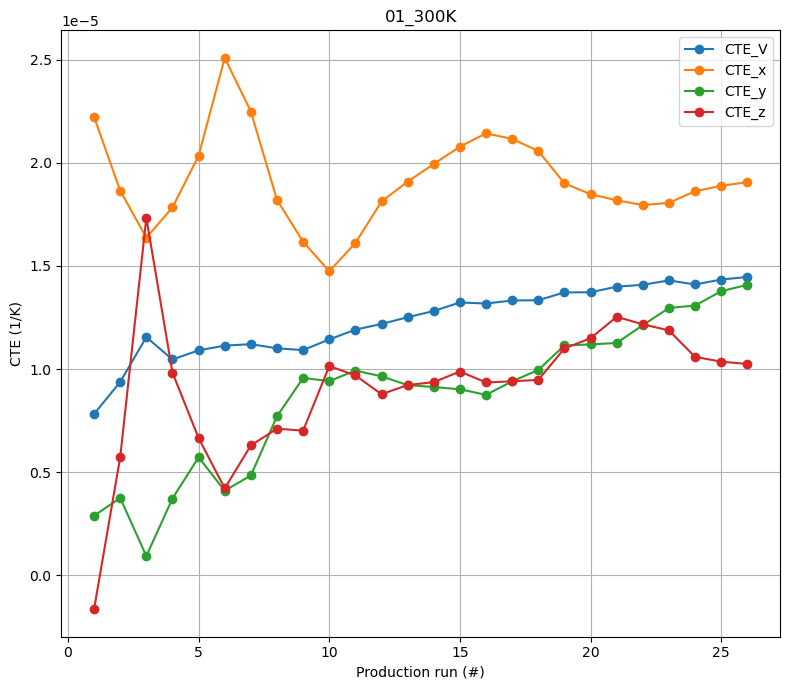

In [75]:
# Plotting of the CTE results as function of production run number
fig, ax = plt.subplots(1, figsize=(8, 7))

ax.plot(
    range(1, len(ploting_data["CTE_V"]) + 1),
    np.array(ploting_data["CTE_V"])
    / 3,  # to convert volumetric CTE to averaged linear CTE
    marker="o",
    label="CTE_V",
)
ax.plot(
    range(1, len(ploting_data["CTE_x"]) + 1),
    ploting_data["CTE_x"],
    marker="o",
    label="CTE_x",
)
ax.plot(
    range(1, len(ploting_data["CTE_y"]) + 1),
    ploting_data["CTE_y"],
    marker="o",
    label="CTE_y",
)
ax.plot(
    range(1, len(ploting_data["CTE_z"]) + 1),
    ploting_data["CTE_z"],
    marker="o",
    label="CTE_z",
)

ax.set_title(f"{T_key}")
ax.grid(True)
ax.set_xlabel("Production run (#)")
ax.set_ylabel("CTE (1/K)")
ax.legend()
fig.tight_layout()

In the CTE plot above we show the evolution of the volume and lattice parameters as function of the production run number for the 300 K simulation. After the 26th production run, all CTE values have converged according to the specified criterion of 5e-7 K^-1. The final volumetric CTE is `4.34e-5 / 3 = 1.45e-5` K^-1. The structural model with 10,000 is still rather small. Therefore, is is not surprising that anisotropic CTEs for the individual dimensions are observed. With larger models a more isotropic behavior is expected.

Let us also investigate the change in lattice parameters below:

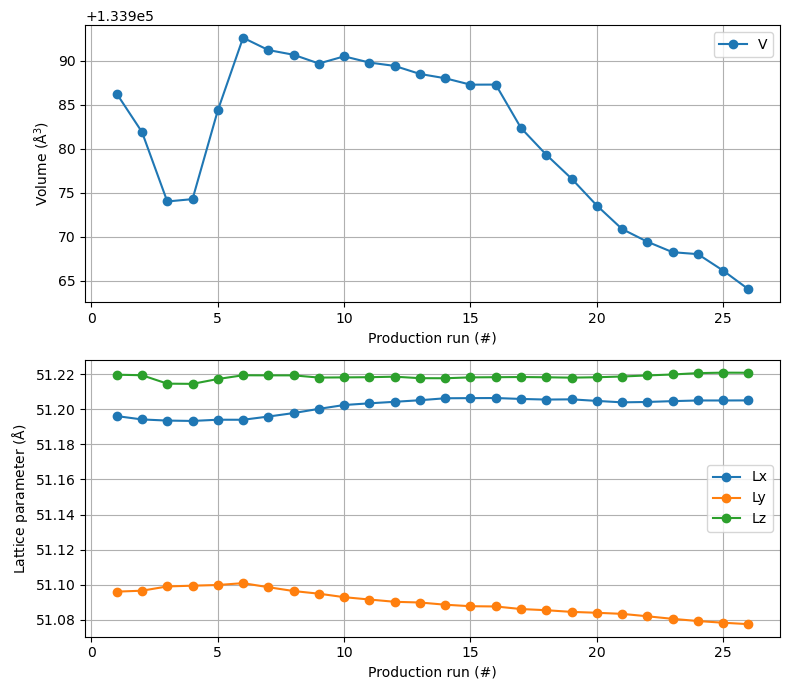

In [76]:
# Plotting of lattice parameters and volume as function of production run number
fig, (ax1, ax2) = plt.subplots(2, figsize=(8, 7))

ax1.plot(
    range(1, len(ploting_data["V"]) + 1),
    np.array(ploting_data["V"]),
    marker="o",
    label="V",
)
ax2.plot(
    range(1, len(ploting_data["Lx"]) + 1),
    ploting_data["Lx"],
    marker="o",
    label="Lx",
)
ax2.plot(
    range(1, len(ploting_data["Ly"]) + 1),
    ploting_data["Ly"],
    marker="o",
    label="Ly",
)
ax2.plot(
    range(1, len(ploting_data["Lz"]) + 1),
    ploting_data["Lz"],
    marker="o",
    label="Lz",
)

# .set_title(f"{T_key}")
ax1.grid(True)
ax1.set_xlabel("Production run (#)")
ax1.set_ylabel(r"Volume ($\mathrm{\AA}^3$)")
ax1.legend()

ax2.grid(True)
ax2.set_xlabel("Production run (#)")
ax2.set_ylabel(r"Lattice parameter ($\mathrm{\AA}$)")
ax2.legend()

fig.tight_layout()

Above, we plot the evolution of the lattice parameters as function of the production run number. After an initial drop and increase in volume, a general downward trend is observed starting from the 6th run to end of the simulation. The magnitude of the change is rather small at 300 K. However, at higher temperatures relaxation processes are accelerated and more pronounced changes can be expected, which would complicate any CTE computation that relies on dV/dT.